# Creating synthetic-wave imagery data like our GOES16

#### 0. Grab an image: DIFFERENT AT EACH TIME (real evolution happens)
#### 1. Interpolate image into a netCDF file from GOES16
#### 3a. put in wave brightness B modulation by wave z', dB_dlogz
#### 3b. put in warping (pixels remapped) by wave velocity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
import xarray as xr 

import scipy 
from scipy import ndimage
# Warping: https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.map_coordinates.html

In [15]:
from glob import glob 

filenames = sorted( glob('DATA/*2022_09_06*png') )
filenames

# Image data for backdrop of synthetic dataset
#!ls -1 DATA/*png

['DATA/image_0_2022_09_06_15_15_00Z.png',
 'DATA/image_1_2022_09_06_15_45_00Z.png',
 'DATA/image_2_2022_09_06_16_15_00Z.png',
 'DATA/image_3_2022_09_06_16_45_00Z.png',
 'DATA/image_4_2022_09_06_17_15_00Z.png',
 'DATA/image_5_2022_09_06_17_45_00Z.png',
 'DATA/image_6_2022_09_06_18_15_00Z.png',
 'DATA/image_7_2022_09_06_18_45_00Z.png',
 'DATA/image_8_2022_09_06_19_15_00Z.png',
 'DATA/image_9_2022_09_06_19_45_00Z.png']

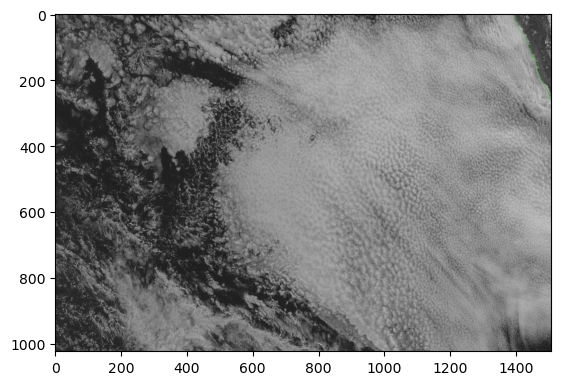

In [51]:
img = imageio.v2.imread(filenames[0])
imagename = "closed_realmotion" 
plt.imshow(img)

#img = imageio.v2.imread('DATA/image_2_2022_09_08_15_54_00Z.png')
red = img[0:,450:,0] # just the red channel and just 400:end in the x dir
red = np.flipud(red)  # for pcolormesh, rather than imshow which has y increase downward on page 

# red.shape[0], red.shape[1]  # y, x on page

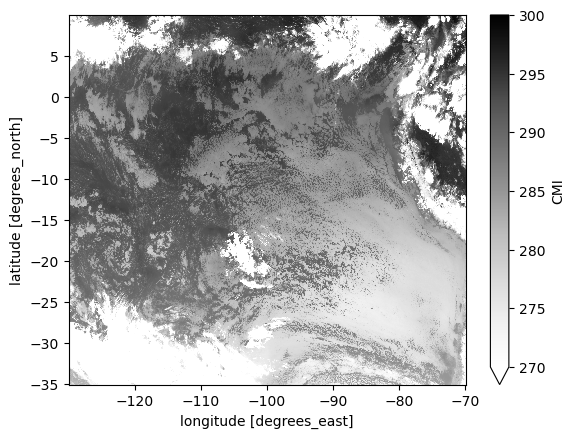

In [17]:
# Read our satellite data (.nc file), to match its 2D size using the image data 

#!ls /Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_09_28_01_15.nc
ds = xr.open_dataset('/Users/bmapes/Box/GWaves_2023_10_11-14_SEPAC/IR/Data/IR_2023_09_28_01_15.nc')
ds.CMI.plot(cmap='Greys', vmin=270, vmax=300);

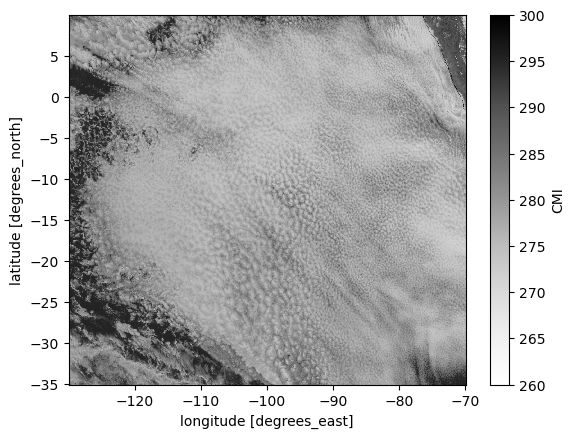

In [18]:
# Replace values and rescale to be in [270,300] K

# 1. Get the dimension names (('latitude', 'longitude'))
dim_names = ds.CMI.dims

#img = imageio.v2.imread('DATA/image_2_2022_09_08_15_54_00Z.png')
red = img[0:,450:,0] # just the red channel and just 400:end in the x dir
red = np.flipud(red)  # for pcolormesh, rather than imshow which has y increase downward on page 

# 2. Create a DataArray from 'red' with correctly defined coordinates,
#    then interpolate it to ds.CMI's exact grid and assign.
red_da_for_interp = xr.DataArray(
    red,
    dims=dim_names,
    coords={
        dim_names[0]: np.linspace(ds.CMI.coords[dim_names[0]].min().values, ds.CMI.coords[dim_names[0]].max().values, red.shape[0]),
        dim_names[1]: np.linspace(ds.CMI.coords[dim_names[1]].min().values, ds.CMI.coords[dim_names[1]].max().values, red.shape[1])
    }
)

# Make this vis image similar in numerical range to the IR data it mimics
ds['CMI'] = 300- red_da_for_interp.interp_like(ds.CMI) *30/200.
ds.CMI.plot(cmap='Greys', vmin=260,vmax=300);

## Coordinates to manipulate image, put waves into it 

In [19]:
# In order to advect and put waves into the image, 
# Get the dimensions of the data array
height, width = ds.CMI.shape[:2]

# Create 2D arrays of x and y
x = np.arange(width)
y = np.arange(height)
X, Y = np.meshgrid(x, y)

# Pixel size: nominal, for MKS units to pixel units. 0.04 deg ~ 4.44km in latitude
DX = 4000             # m, pixel size (nominal, for wave computations) (0.04 degrees)
print('pixel size in deg: ', ds.longitude.diff(dim='longitude').mean().values)

# Xm and Ym are Coordinates in meters, distances measured from central point 
Xm = (X-X.mean())*DX
Ym = (Y-Y.mean())*DX 

pixel size in deg:  0.04


-------------------

# Wave parameters for advecting, warping, and brightness-modulating an image

"In one period, 7–9 October 2008, the waves modulated cloud-top-height by up to 400 m peak-to-trough, propagating perpendicular to the synoptic boundary layer flow with phase speed 15.3 m s−1, period ∼1 h and horizontal wavelength 55 km. The gravity waves were observed to be non-dispersive. “ from https://doi.org/10.1002/qj.1952

For a wave moving toward 45 degrees (northeast), define k and l as positive (sin and cos of nav angle). Let's take z = sin( k(x-ct) + l(y-ct) ) which is indeed moving NEward with time. Then u and v are both positive at z crests (sketch it). That means dx and dy are positive when time is 1/4 period later, or when 90deg of phase have been subtracted since t appears with a negative sign in the formula for phase (x-ct). 

In [20]:
!mkdir ~/Box/GWaves_Synthetic_G16ncfiles/

mkdir: /Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/: File exists


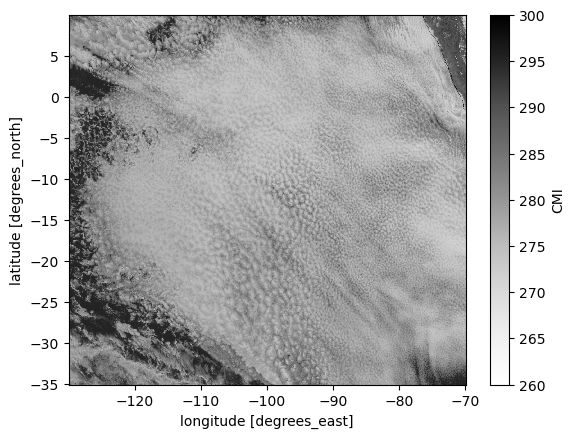

In [23]:
# VERSION USES FILENAMES LIST TO INCLUDE ACTUAL TIME EVOLUTION 

# Write as frames in a folder with name reflecting the parameters
FOLDERNAME = '~/Box/GWaves_Synthetic_G16ncfiles/'

# Get the image: IR type view ("CMI")
ds['CMI'] = 300- red_da_for_interp.interp_like(ds.CMI) *30/200.
ds.CMI.plot(cmap='Greys', vmin=260,vmax=300);
img = np.flipud( ds.CMI.to_numpy() )

# Constants for this animation  
time_steps = 10           # Number of time steps 
time_resolution = 1800   # seconds, half an hour is our GOES16 data
PBLdepth = 1000          # m, divergent winds assumed to be constant through this layer  
dB_dlogz = 10             # Brightness modulation per dz: grid' *= (1 + (dz/PBLdepth)* dB_dlogz)  

# Mean wind: SE-NW and with divergence NO WIND FOR ACTUAL EVOLUTION
U = 0                # m/s
dUdx = 0e-6           # /s, 1e-5 is 1 m/s per 100km diffluence
V =  0                # m/s 
dVdy = 0e-6           # /s, 1e-5 is 1 m/s per 100km diffluence

# Larger-scale (non wave) velocity for advecting pixels 
u = U + dUdx*Xm   
v = V + dVdy*Ym   

# The numpy array, to contain output image-set animation 
advected = np.zeros((height, width, time_steps))

# Fill it with img, advected by the mean (mildly divergent) flow 
for it in range(time_steps):
    t = it*time_resolution     # t is in seconds 
    #advected[:,:,it] = ndimage.map_coordinates(img,[Y- v*t/DX, X- u*t/DX], mode='mirror')  #mode='grid-wrap' )

    # Read a fresh image each time 
    img = imageio.v2.imread(filenames[it])
    red = img[0:,450:,0] # just the red channel and just 400:end in the x dir
    red = np.flipud(red)  # for pcolormesh, rather than imshow which has y increase downward on page 
    red_da_for_interp = xr.DataArray(
        red,
        dims=dim_names,
        coords={
            dim_names[0]: np.linspace(ds.CMI.coords[dim_names[0]].min().values, 
                                      ds.CMI.coords[dim_names[0]].max().values, red.shape[0]),
            dim_names[1]: np.linspace(ds.CMI.coords[dim_names[1]].min().values, 
                                      ds.CMI.coords[dim_names[1]].max().values, red.shape[1])
        }
    )
    # Make this vis image similar in numerical range to the IR data it mimics
    ds['CMI'] = 300- red_da_for_interp.interp_like(ds.CMI) *30/200.
    #ds.CMI.plot(cmap='Greys', vmin=260,vmax=300);
    
    advected[:,:,it] = np.flipud( ds.CMI.to_numpy() )

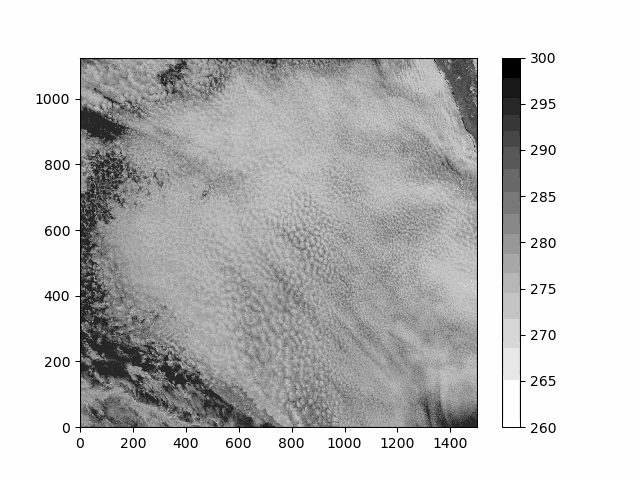

In [24]:
import gif 
from IPython.display import Image
disp = advected.copy()
NT = disp.shape[2]

@gif.frame
def plot_frame(i):
    plt.pcolormesh(disp[:,:,i], cmap='Greys', vmin=260,vmax=300); plt.colorbar();

#Generate frames and save to a gif
frames = [plot_frame(i) for i in range(NT)]
gif.save(frames, 'example.gif', duration=500)
Image(filename='example.gif')

In [44]:
# def envelope for Gaussian envelope, def putwave for modulation and warping 
def envelope(Xm, Ym, xcenter, ycenter, length, aspect, angle_deg):
    """
    Creates a 2D elliptical Gaussian blob on a given coordinate grid. Gemini write this. 

    Args:
        Xm (numpy.ndarray): 2D array of x-coordinates (e.g., from np.meshgrid).
        Ym (numpy.ndarray): 2D array of y-coordinates (e.g., from np.meshgrid).
        xcenter (float): x-coordinate of the blob's center.
        ycenter (float): y-coordinate of the blob's center.
        length (float): Standard deviation along the blob's major axis (controls overall size).
                        This is your 'blob_size'.
        aspect (float): Ratio of major to minor axis standard deviation (elongation, >= 1).
                        If < 1, axes are swapped and angle adjusted.
        angle_deg (float): Angle of the major axis in degrees, relative to the x-axis.

    Returns:
        numpy.ndarray: A 2D array representing the elliptical Gaussian blob.
                       Peak amplitude is 1.0 at the center.
    """
    # Ensure aspect ratio is >= 1; if not, swap major/minor axes and adjust angle by 90 degrees
    if aspect < 1.0:
        aspect = 1.0 / aspect
        angle_deg += 90.0

    angle_radians = np.deg2rad(angle_deg)
    sigma_major = length
    sigma_minor = length / aspect

    # Translate coordinates relative to the blob's center
    Xt = Xm - xcenter
    Yt = Ym - ycenter

    # Rotate the translated coordinates to align with the blob's principal axes
    Xr = Xt * np.cos(angle_radians) + Yt * np.sin(angle_radians)
    Yr = -Xt * np.sin(angle_radians) + Yt * np.cos(angle_radians)

    # Calculate the elliptical Gaussian value at each point
    gaussian_blob = np.exp(-(Xr**2 / (2 * sigma_major**2) + Yr**2 / (2 * sigma_minor**2)))

    return gaussian_blob
    
def put_wave(grid, cphase = 14,zamplitude = 100,wavelength = 256*1000.,direction = 215,\
             xcenter=500*1000, ycenter=-500*1000, length=1500*1000.,aspect=3, angle_deg=60):
    
    # Wave properties
    #cphase = 14            # m/s
    #amplitude = 100       # meters, vertical displacement
    #wavelength = 256*1000. # meters
    #direction = 215       # navigation angle of FROM direction in degrees (215 = FROM WSW) 
    # Amplitude modulation by a big smooth Gaussian, elongation only N-S for now 
    #packet_center_x = 1000*1000.  # meters from center of Xm, Ym coordinates  
    #packet_center_y = 0         # pixels from center of Xm, Ym coordinates  
    #packet_width_x  = 800*1000.  # meters! 
    #packet_width_y  = 1000*1000.  # meters! 
    # period = wavelength/cphase 
    
    ## Construct it: 

    k = 2*np.pi/wavelength * np.sin( (direction) *np.pi/180 )   # add 1e-9 in case of 0 denominator
    l = 2*np.pi/wavelength * np.cos( (direction) *np.pi/180 )   # add 1e-9 in case of 0 denominator
    Ampwindow = envelope(Xm, Ym, xcenter, ycenter, length, aspect, angle_deg)  

    for it in range(time_steps):
        t = it*time_resolution     # t is in seconds 
    # dz measures vertical displacements: choose sin(x-ct) phase
        dz = zamplitude*np.sin( k*(Xm - cphase*t)+l*(Ym - cphase*t) ) *Ampwindow

    # wave dx and dy are 90deg behind phase with dz, prop. to wavelength. 
        dxy = (zamplitude/PBLdepth)*wavelength \
              * np.sin( k*(Xm - cphase*t)+l*(Ym - cphase*t) -np.pi/2.) /DX
        dx = dxy * np.sin(direction *np.pi/180.) *Ampwindow 
        dy = dxy * np.cos(direction *np.pi/180.) *Ampwindow

    # Warping by transporting pixels in image, wrapping (periodic) for now. SUBTRACT dy and dx in argument. 
        grid[:,:,it] = ndimage.map_coordinates(grid[:,:,it], \
                                [Y-dy, X-dx], mode='mirror' ) # mirror uses nearby texture
        
    # Modulate (multiply anomalous brightness) by vertical displacement, bright where scrunched 
        #meanval = np.mean(grid[:,:,it])
        #grid[:,:,it] = meanval + (grid[:,:,it]-meanval) * (1 - (dz/PBLdepth)* dB_dlogz)  

    # Modulate (multiply CLOUD brightness) by vertical displacement 
        meanval = np.mean(grid[:,:,it])
        grid[:,:,it] = np.where(grid[:,:,it] < 290, \
                                meanval+( (grid[:,:,it]-meanval) * (1 - (dz/PBLdepth)* dB_dlogz)), \
                                grid[:,:,it])

    return grid 

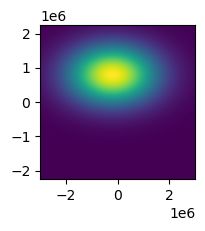

In [45]:
# Playground for envelope specification 

plt.figure(figsize=(2,2))
plt.pcolormesh(Xm, Ym, envelope(Xm, Ym, \
             xcenter=-200*1000, ycenter=800*1000, length=1200*1000.,aspect=2, angle_deg=0));

In [48]:
# Put waves into NON-advected images (again, looped)
disp = advected.copy() 

disp = put_wave(disp, cphase = 15,zamplitude = 50,wavelength = 256*1000.,direction = 140,\
             xcenter=-1000*1000, ycenter=-1000*1000, length=500*1000.,aspect=1.5, angle_deg=120)

disp = put_wave(disp, cphase = -15,zamplitude = 50,wavelength = 512*1000.,direction = 90,\
             xcenter=-200*1000, ycenter=800*1000, length=1200*1000.,aspect=2, angle_deg=0)

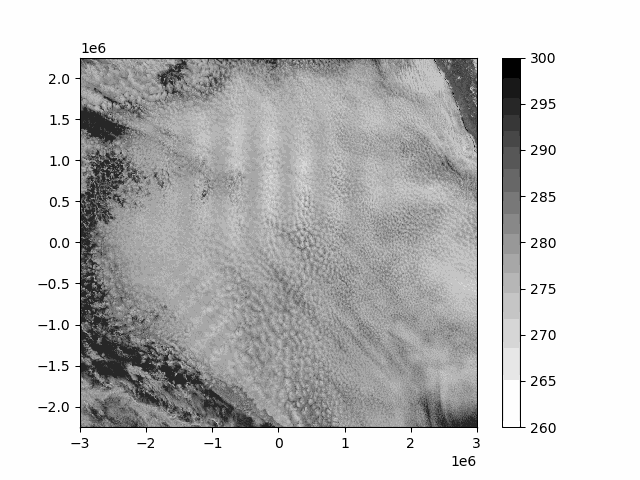

In [49]:
NT = disp.shape[2]

@gif.frame
def plot_frame(i):
    plt.pcolormesh(Xm, Ym, disp[:,:,i], cmap='Greys', vmin=260,vmax=300); plt.colorbar();

#Generate frames and save to a gif
frames = [plot_frame(i) for i in range(NT)]
gif.save(frames, 'example.gif', duration=500)
Image(filename='example.gif')

In [60]:
disp.shape

(1125, 1500, 10)

In [52]:
#!ls -atl ~/Box/GWaves_Synthetic_G16ncfiles/

In [61]:
# Save images as .nc files of the right shape and size for satellite data 
# filename: scene_IR_128km_45deg_amp3_envcenter_realistic 

for it in range(disp.shape[2]):
    ds['CMI'].values = np.flipud(disp[:,:,it])
    filename = FOLDERNAME+imagename+'_IR_2waves_halfhour'+str(it)+'.nc'
    print(filename)
    ds.to_netcdf(filename, mode='w')  # overwrite if it exists already

~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour0.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour1.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour2.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour3.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour4.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour5.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour6.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour7.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour8.nc
~/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour9.nc


In [62]:
# Test it by making another gif from the .nc files, using ~/Box for Hanna-Brian generality
# Since they have no time dimension, we need a trick to open them as a mfdataset

import glob
import os

# Expand the tilde to the home directory
pattern = os.path.expanduser(FOLDERNAME+imagename+"*.nc")

# Get list of files
files = sorted(glob.glob(pattern))

# Open each file and add a new 'time' coordinate
datasets = [xr.open_dataset(f).assign_coords(time=i) for i, f in enumerate(files)]

# Concatenate along the new 'time' dimension
ds = xr.concat(datasets, dim='time')
ds

<xarray.Dataset> Size: 135MB
Dimensions:    (time: 10, latitude: 1125, longitude: 1500)
Coordinates:
  * latitude   (latitude) float32 4kB 9.94 9.9 9.86 ... -34.94 -34.98 -35.02
  * longitude  (longitude) float32 6kB -129.9 -129.9 -129.9 ... -70.02 -69.98
  * time       (time) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    CMI        (time, latitude, longitude) float64 135MB 292.4 293.6 ... 281.7
Attributes: (12/28)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    Metadata_Conventions:      Unidata Dataset Discovery v1.0
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    ...                        ...
    time_coverage_start:       2023-09-28T01:20:20.7Z
    time_coverage_end:         2023-09-28T01:29:52.7Z
    timeline_id:               ABI Mode 6
    production_data_source:    Realtime
    id:                        daa056ab-c52c-4395-b0fd-6de80fb17536
    history:                   2024-11-01 15:32:36: Resampled to regular lat-...

In [63]:
files

['/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour0.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour1.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour2.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour3.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour4.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour5.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour6.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour7.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour8.nc',
 '/Users/bmapes/Box/GWaves_Synthetic_G16ncfiles/closed_realmotion_IR_2waves_halfhour9.nc']

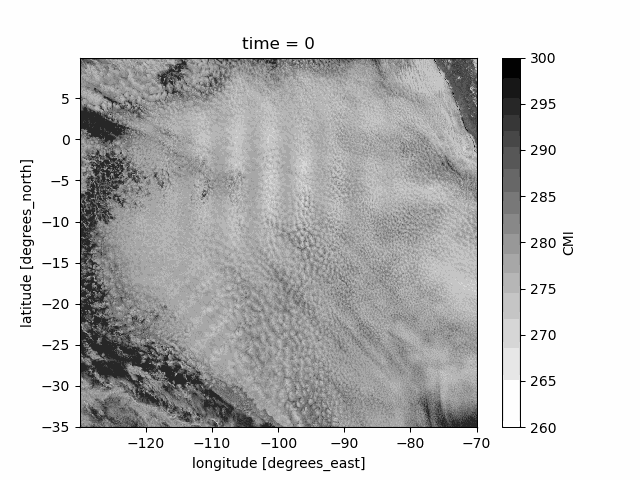

In [64]:
NT = ds.time.size

@gif.frame
def plot_frame(i):
    ds.CMI[i].plot(cmap='Greys', vmin=260,vmax=300);

#Generate frames and save to a gif
frames = [plot_frame(i) for i in range(NT)]
gif.save(frames, 'test.gif', duration=500)
Image(filename='test.gif')